# FASE 1 — Pipeline de Datos con MONAI
Construimos el pipeline completo de preprocesamiento y data augmentation.

**Reglas críticas:**
- Augmentations (rotaciones, ruido, flips) → **solo en train**
- Val y Test → **solo normalización** (sin data leakage)
- Toda transformación usa **exclusivamente MONAI Transforms**

## 1. Imports

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from medmnist import DermaMNIST, INFO

# MONAI Transforms — solo usamos esto para transformaciones
from monai.transforms import (
    Compose,
    ToTensor,
    RandFlip,
    RandRotate,
    RandZoom,
    RandGaussianNoise,
    RandAdjustContrast,
    NormalizeIntensity,
    RandGaussianSmooth,
    RandHistogramShift,
    ScaleIntensity,
)

# Valores calculados en Fase 0
MEAN = [0.7631, 0.5381, 0.5614]
STD  = [0.1365, 0.1542, 0.1691]
CLASS_WEIGHTS = [4.3904, 2.7883, 1.3017, 12.5125, 1.285, 0.2133, 10.1111]

info = INFO['dermamnist']
CLASS_NAMES = list(info['label'].values())
NUM_CLASSES = len(CLASS_NAMES)

print('✅ Imports OK')
print(f'   Clases: {NUM_CLASSES}')
print(f'   MEAN  : {MEAN}')
print(f'   STD   : {STD}')

✅ Imports OK
   Clases: 7
   MEAN  : [0.7631, 0.5381, 0.5614]
   STD   : [0.1365, 0.1542, 0.1691]


## 2. Definición de Transforms

### ¿Por qué cada transformación?
| Transform | Justificación clínica |
|-----------|----------------------|
| `RandFlip` | Las lesiones pueden aparecer en cualquier orientación |
| `RandRotate` | Invarianza rotacional (lesiones circulares/irregulares) |
| `RandZoom` | Variación en distancia de captura dermoscópica |
| `RandGaussianNoise` | Simula ruido del sensor de la cámara |
| `RandAdjustContrast` | Variaciones de iluminación entre dispositivos |
| `NormalizeIntensity` | Estandariza con la media/std del train set |

In [2]:
# ─────────────────────────────────────────────
# TRAIN: preprocesamiento + augmentation
# ─────────────────────────────────────────────
train_transforms = Compose([
    # 1. Normalizar con media/std del train set
    NormalizeIntensity(
        subtrahend=MEAN,
        divisor=STD,
        channel_wise=True
    ),
    # 2. Flip horizontal aleatorio (50% probabilidad)
    RandFlip(
        spatial_axis=1,
        prob=0.5
    ),
    # 3. Flip vertical aleatorio (50% probabilidad)
    RandFlip(
        spatial_axis=0,
        prob=0.5
    ),
    # 4. Rotación aleatoria ±30 grados
    RandRotate(
        range_x=0.52,   # ~30 grados en radianes
        prob=0.7,
        keep_size=True,
        padding_mode='reflection'
    ),
    # 5. Zoom aleatorio entre 0.85x y 1.15x
    RandZoom(
        min_zoom=0.85,
        max_zoom=1.15,
        prob=0.5,
        keep_size=True,
        padding_mode='reflect'
    ),
    # 6. Ruido gaussiano (simula sensor)
    RandGaussianNoise(
        prob=0.3,
        mean=0.0,
        std=0.05
    ),
    # 7. Ajuste de contraste aleatorio
    RandAdjustContrast(
        prob=0.3,
        gamma=(0.75, 1.5)
    ),
])

# ─────────────────────────────────────────────
# VAL / TEST: SOLO normalización (sin augmentation)
# ─────────────────────────────────────────────
val_test_transforms = Compose([
    NormalizeIntensity(
        subtrahend=MEAN,
        divisor=STD,
        channel_wise=True
    ),
])

print('✅ Transforms definidos')
print(f'   Train  : {len(train_transforms.transforms)} transformaciones')
print(f'   Val/Test: {len(val_test_transforms.transforms)} transformación (solo normalización)')

✅ Transforms definidos
   Train  : 7 transformaciones
   Val/Test: 1 transformación (solo normalización)


## 3. Dataset Wrapper
Creamos una clase `DermaMNISTDataset` que integra DermaMNIST con nuestras MONAI transforms.

In [ ]:
class DermaMNISTDataset(Dataset):
    """
    Wrapper sobre DermaMNIST que aplica MONAI transforms.
    
    La imagen llega como PIL (H, W, C) desde medmnist.
    La convertimos a tensor (C, H, W) float32 antes de
    aplicar las MONAI transforms.
    """
    def __init__(self, split: str, transform=None):
        assert split in ('train', 'val', 'test')
        # Descargamos sin transform (lo hacemos nosotros)
        from torchvision import transforms as tv_transforms
        self.dataset = DermaMNIST(
            split=split,
            transform=tv_transforms.ToTensor(),  # PIL → tensor (C,H,W) float [0,1]
            download=True
        )
        self.transform = transform
        self.split = split

    def __len__(self):
        return len(self.dataset)


    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        # img: tensor (3, 28, 28) float32 en [0, 1]
        # Aplicar MONAI transforms
        if self.transform:
            img = self.transform(img)
        # label: tensor shape (1,) → int escalar
        label = torch.tensor(label).long().squeeze()
        return img, label

    def get_labels(self):
        """Retorna todos los labels (para WeightedRandomSampler)"""
        return [int(self.dataset[i][1]) for i in range(len(self))]


# Instanciar los 3 splits
train_ds = DermaMNISTDataset('train', transform=train_transforms)
val_ds   = DermaMNISTDataset('val',   transform=val_test_transforms)
test_ds  = DermaMNISTDataset('test',  transform=val_test_transforms)

print(f'Train dataset : {len(train_ds):,} muestras')
print(f'Val   dataset : {len(val_ds):,} muestras')
print(f'Test  dataset : {len(test_ds):,} muestras')

# Verificar shape
img, label = train_ds[0]
print(f'\nShape imagen  : {img.shape}')
print(f'Tipo label    : {label} (dtype={label.dtype})')

Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz
Train dataset : 7,007 muestras
Val   dataset : 1,003 muestras
Test  dataset : 2,005 muestras

Shape imagen  : torch.Size([3, 28, 28])
Tipo label    : 0 (dtype=torch.int64)


## 4. WeightedRandomSampler — Manejo del Desbalance

En vez de solo usar `class_weights` en la loss, también balanceamos el **muestreo** durante el entrenamiento.
Esto garantiza que el modelo vea clases minoritarias con más frecuencia en cada batch.

In [5]:
# Construir sampler para el train set
train_labels = train_ds.get_labels()
class_weights_tensor = torch.FloatTensor(CLASS_WEIGHTS)

# Asignar a cada muestra el peso de su clase
sample_weights = torch.tensor([CLASS_WEIGHTS[label] for label in train_labels])

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True  # necesario para oversampling de clases minoritarias
)

print('✅ WeightedRandomSampler creado')
print(f'   Muestras por época: {len(sampler):,}')
print()

# Verificar: simular una época y contar distribución efectiva
counts_sim = np.zeros(NUM_CLASSES, dtype=int)
for idx in sampler:
    counts_sim[train_labels[idx]] += 1

print('Distribución efectiva con sampler (1 época simulada):')
for i, (name, c) in enumerate(zip(CLASS_NAMES, counts_sim)):
    pct = c / counts_sim.sum() * 100
    bar = '█' * int(pct / 1.5)
    print(f'  [{i}] {name[:28]:<28} {c:>5} ({pct:4.1f}%) {bar}')

C:\Users\isape\AppData\Local\Temp\ipykernel_19828\1114563190.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return [int(self.dataset[i][1]) for i in range(len(self))]


✅ WeightedRandomSampler creado
   Muestras por época: 7,007

Distribución efectiva con sampler (1 época simulada):
  [0] actinic keratoses and intrae   955 (13.6%) █████████
  [1] basal cell carcinoma          1023 (14.6%) █████████
  [2] benign keratosis-like lesion  1054 (15.0%) ██████████
  [3] dermatofibroma                 972 (13.9%) █████████
  [4] melanoma                       997 (14.2%) █████████
  [5] melanocytic nevi               991 (14.1%) █████████
  [6] vascular lesions              1015 (14.5%) █████████


## 5. DataLoaders

In [6]:
BATCH_SIZE = 64
NUM_WORKERS = 0  # En Windows usar 0 para evitar problemas con multiprocessing

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,        # usa WeightedRandomSampler (NO shuffle)
    num_workers=NUM_WORKERS,
    pin_memory=True,        # acelera transferencia CPU→GPU
    drop_last=True          # descarta el último batch incompleto
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f'✅ DataLoaders creados')
print(f'   Batch size    : {BATCH_SIZE}')
print(f'   Train batches : {len(train_loader)}')
print(f'   Val batches   : {len(val_loader)}')
print(f'   Test batches  : {len(test_loader)}')

✅ DataLoaders creados
   Batch size    : 64
   Train batches : 109
   Val batches   : 16
   Test batches  : 32


## 6. Verificación del Pipeline — Sanity Check

In [7]:
# Tomar un batch y verificar shapes, tipos, rango de valores
imgs, labels = next(iter(train_loader))

print('=== SANITY CHECK: Batch de entrenamiento ===')
print(f'imgs.shape  : {imgs.shape}   → (batch, canales, H, W)')
print(f'labels.shape: {labels.shape} → (batch,)')
print(f'imgs.dtype  : {imgs.dtype}')
print(f'labels.dtype: {labels.dtype}')
print(f'Rango imgs  : [{imgs.min():.3f}, {imgs.max():.3f}]  (normalizado, puede ser negativo)')
print(f'Clases en batch: {sorted(labels.unique().tolist())}')
print()

# Verificar que val NO tiene valores raros
imgs_v, labels_v = next(iter(val_loader))
print('=== SANITY CHECK: Batch de validación ===')
print(f'imgs.shape  : {imgs_v.shape}')
print(f'Rango imgs  : [{imgs_v.min():.3f}, {imgs_v.max():.3f}]')
print()
print('✅ Pipeline OK — las imágenes están normalizadas correctamente')

=== SANITY CHECK: Batch de entrenamiento ===
imgs.shape  : torch.Size([64, 3, 28, 28])   → (batch, canales, H, W)
labels.shape: torch.Size([64]) → (batch,)
imgs.dtype  : torch.float32
labels.dtype: torch.int64
Rango imgs  : [-5.389, 2.477]  (normalizado, puede ser negativo)
Clases en batch: [0, 1, 2, 3, 4, 5, 6]

=== SANITY CHECK: Batch de validación ===
imgs.shape  : torch.Size([64, 3, 28, 28])
Rango imgs  : [-5.590, 2.594]

✅ Pipeline OK — las imágenes están normalizadas correctamente


## 7. Visualización: Efecto de las Augmentations

Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz


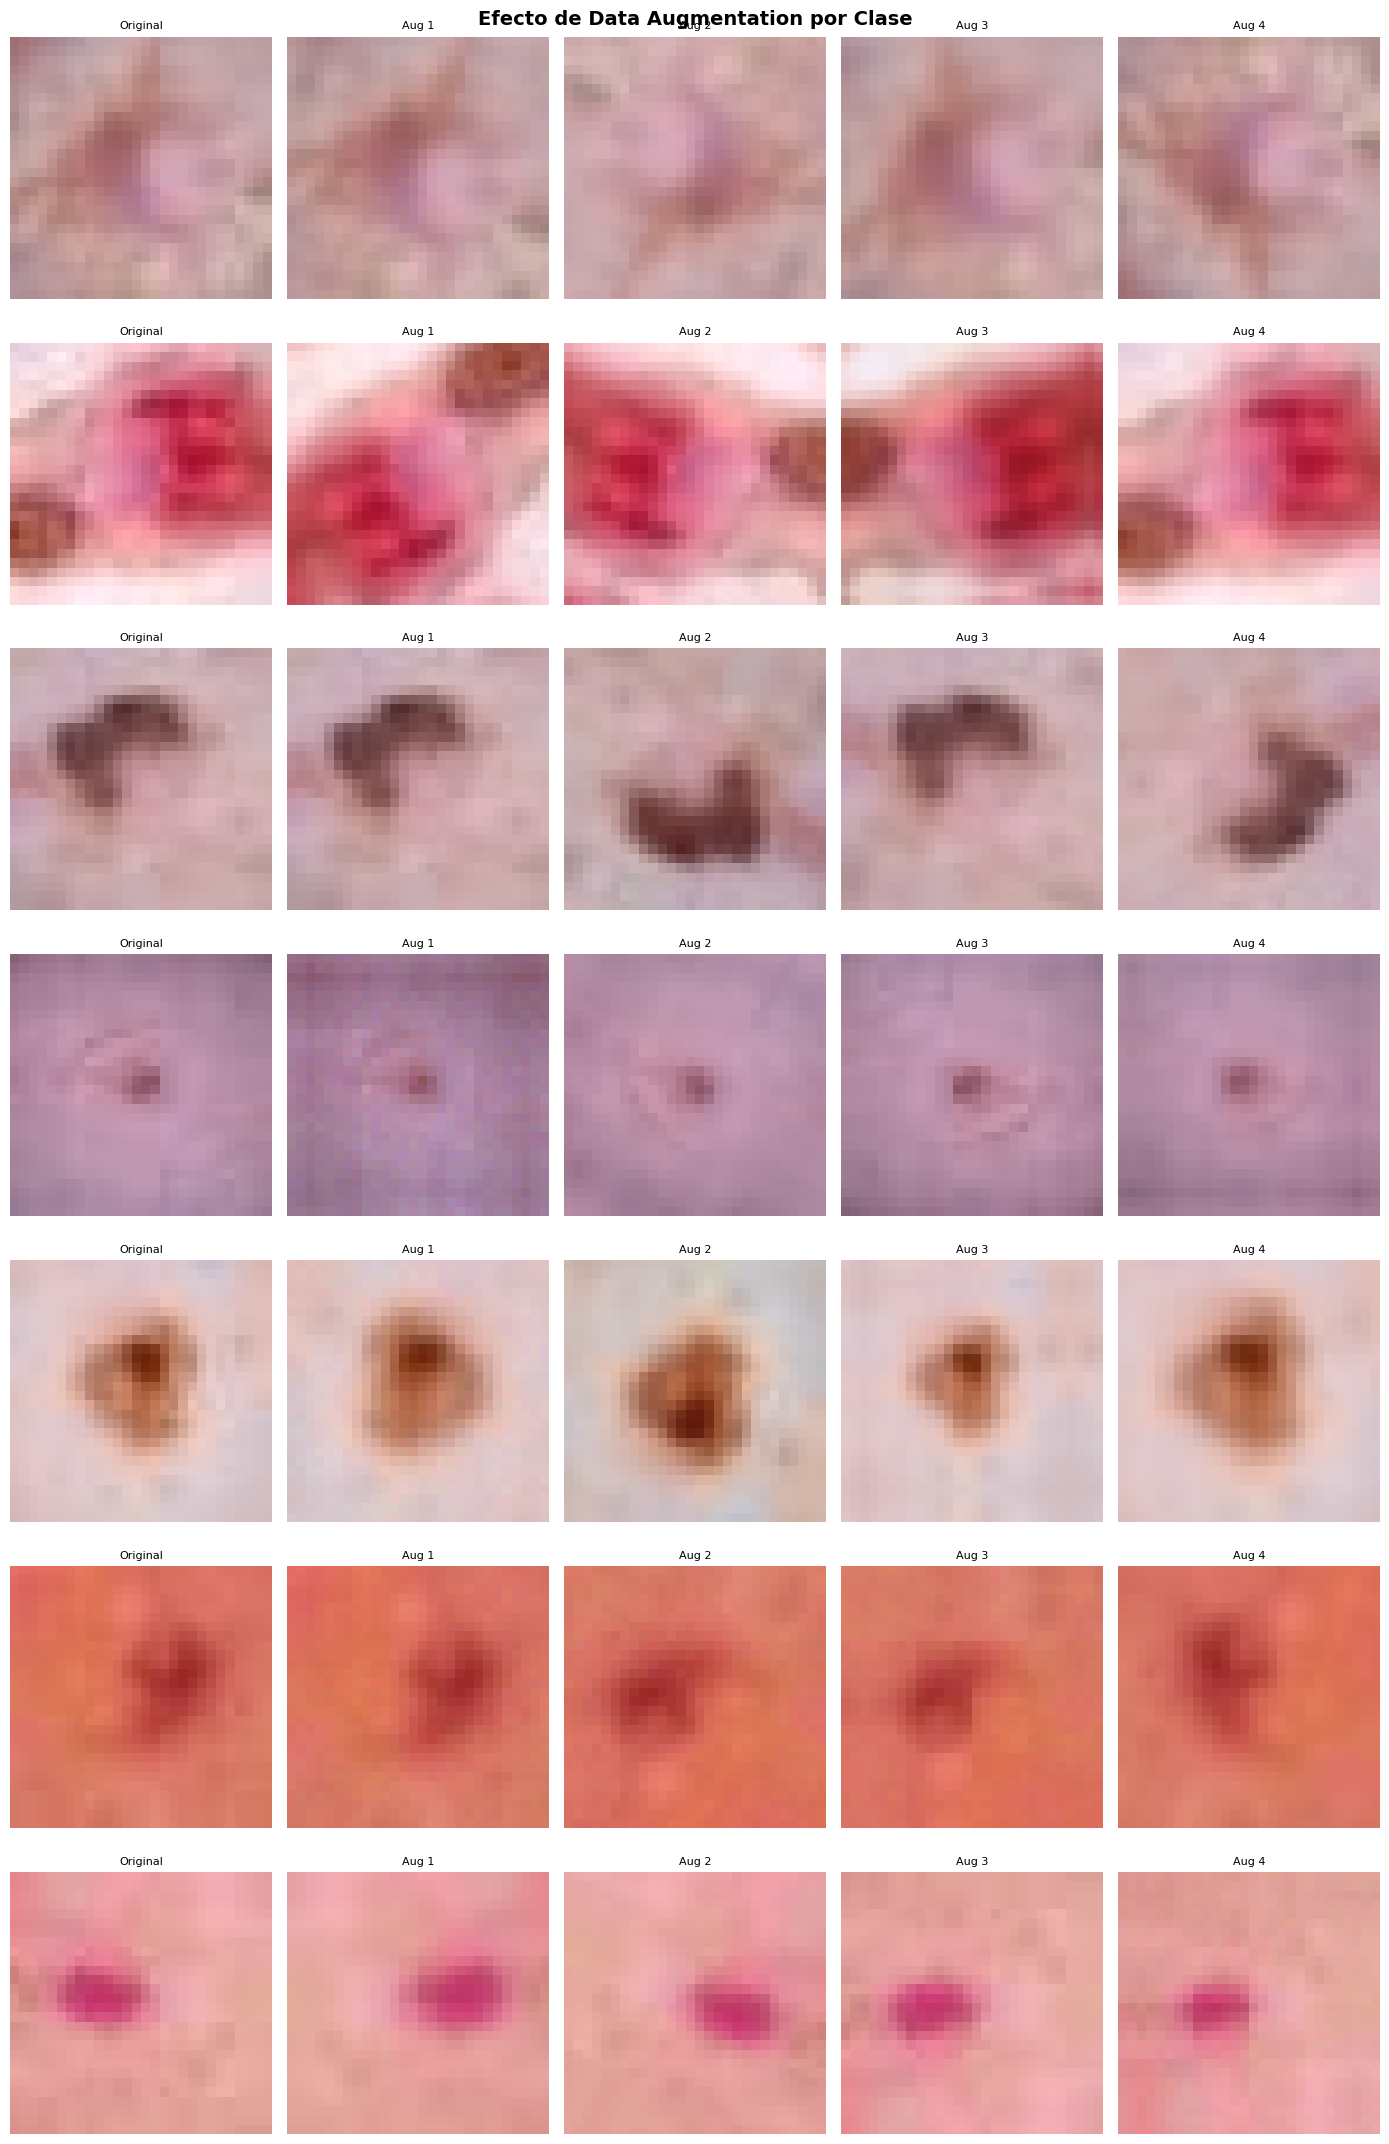

✅ Guardado: augmentation_visualizacion.png


In [8]:
# Mostrar la misma imagen con y sin augmentation para comparar
# Usamos el dataset RAW (sin transform) para la imagen original
raw_ds = DermaMNISTDataset('train', transform=val_test_transforms)  # solo normalización

def denormalize(tensor, mean=MEAN, std=STD):
    """Revertir normalización para visualización"""
    t = tensor.clone()
    for c in range(3):
        t[c] = t[c] * std[c] + mean[c]
    return t.clamp(0, 1).permute(1, 2, 0).numpy()

# Escoger un índice de cada clase
class_example_idx = {}
for idx, (_, label) in enumerate(raw_ds):
    c = int(label)
    if c not in class_example_idx:
        class_example_idx[c] = idx
    if len(class_example_idx) == NUM_CLASSES:
        break

NUM_AUG = 4  # versiones augmentadas a mostrar
fig, axes = plt.subplots(NUM_CLASSES, NUM_AUG + 1, figsize=(14, 22))
fig.suptitle('Efecto de Data Augmentation por Clase', fontsize=14, fontweight='bold')

for row, (class_idx, sample_idx) in enumerate(sorted(class_example_idx.items())):
    # Original (solo normalización)
    img_orig, _ = raw_ds[sample_idx]
    axes[row][0].imshow(denormalize(img_orig))
    axes[row][0].set_title('Original', fontsize=8)
    axes[row][0].axis('off')
    axes[row][0].set_ylabel(f'[{class_idx}]\n{CLASS_NAMES[class_idx][:15]}',
                            fontsize=7, rotation=0, ha='right', va='center')

    # Versiones augmentadas
    for col in range(1, NUM_AUG + 1):
        img_aug, _ = train_ds[sample_idx]  # train_ds aplica augmentation
        axes[row][col].imshow(denormalize(img_aug))
        axes[row][col].set_title(f'Aug {col}', fontsize=8)
        axes[row][col].axis('off')

plt.tight_layout()
plt.savefig('augmentation_visualizacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: augmentation_visualizacion.png')

## 8. Guardar configuración del pipeline
Exportamos todo en un módulo `pipeline.py` reutilizable en las siguientes fases.

In [9]:
pipeline_code = '''
# pipeline.py — Fase 1: Pipeline de datos con MONAI
# Importar en fases posteriores: from pipeline import get_dataloaders, CLASS_NAMES, CLASS_WEIGHTS

import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms as tv_transforms
from medmnist import DermaMNIST, INFO
from monai.transforms import (
    Compose, NormalizeIntensity, RandFlip, RandRotate,
    RandZoom, RandGaussianNoise, RandAdjustContrast,
)

# ── Constantes ──────────────────────────────────────────
MEAN          = [0.7631, 0.5381, 0.5614]
STD           = [0.1365, 0.1542, 0.1691]
CLASS_WEIGHTS = [4.3904, 2.7883, 1.3017, 12.5125, 1.285, 0.2133, 10.1111]
CLASS_NAMES   = list(INFO["dermamnist"]["label"].values())
NUM_CLASSES   = len(CLASS_NAMES)

# ── Transforms ──────────────────────────────────────────
train_transforms = Compose([
    NormalizeIntensity(subtrahend=MEAN, divisor=STD, channel_wise=True),
    RandFlip(spatial_axis=1, prob=0.5),
    RandFlip(spatial_axis=0, prob=0.5),
    RandRotate(range_x=0.52, prob=0.7, keep_size=True, padding_mode="reflection"),
    RandZoom(min_zoom=0.85, max_zoom=1.15, prob=0.5, keep_size=True, padding_mode="reflect"),
    RandGaussianNoise(prob=0.3, mean=0.0, std=0.05),
    RandAdjustContrast(prob=0.3, gamma=(0.75, 1.5)),
])

val_test_transforms = Compose([
    NormalizeIntensity(subtrahend=MEAN, divisor=STD, channel_wise=True),
])

# ── Dataset ─────────────────────────────────────────────
class DermaMNISTDataset(Dataset):
    def __init__(self, split, transform=None):
        self.dataset = DermaMNIST(split=split, transform=tv_transforms.ToTensor(), download=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label.long().squeeze()

    def get_labels(self):
        return [int(self.dataset[i][1]) for i in range(len(self))]

# ── DataLoaders ─────────────────────────────────────────
def get_dataloaders(batch_size=64, num_workers=0):
    train_ds = DermaMNISTDataset("train", transform=train_transforms)
    val_ds   = DermaMNISTDataset("val",   transform=val_test_transforms)
    test_ds  = DermaMNISTDataset("test",  transform=val_test_transforms)

    # Sampler balanceado
    sample_weights = torch.tensor([CLASS_WEIGHTS[l] for l in train_ds.get_labels()])
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler,
                              num_workers=num_workers, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader, test_loader
'''

with open('pipeline.py', 'w', encoding='utf-8') as f:
    f.write(pipeline_code.strip())

# Verificar que importa correctamente
import importlib.util, sys
spec = importlib.util.spec_from_file_location('pipeline', 'pipeline.py')
mod  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

print('✅ pipeline.py guardado y verificado')
print(f'   NUM_CLASSES  : {mod.NUM_CLASSES}')
print(f'   CLASS_NAMES  : {mod.CLASS_NAMES}')

✅ pipeline.py guardado y verificado
   NUM_CLASSES  : 7
   CLASS_NAMES  : ['actinic keratoses and intraepithelial carcinoma', 'basal cell carcinoma', 'benign keratosis-like lesions', 'dermatofibroma', 'melanoma', 'melanocytic nevi', 'vascular lesions']


## ✅ Resumen Fase 1

| Componente | Decisión | Justificación |
|---|---|---|
| Normalización | Media/Std del train set | Calculada en Fase 0, sin data leakage |
| Augmentation train | Flip, Rotate, Zoom, Noise, Contrast | Invarianzas clínicas dermoscópicas |
| Augmentation val/test | **Ninguna** | Evitar data leakage |
| Desbalance | WeightedRandomSampler + class_weights en loss | Doble estrategia: muestreo + penalización |
| num_workers | 0 | Evita deadlocks en Windows con multiprocessing |

**Siguiente paso → Fase 2: Arquitectura CNN Multiescala**